<a href="https://colab.research.google.com/github/shaestasaleem/flyrank-machine-learning-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shaestasaleem/flyrank-machine-learning-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
# Ranking Content for Editorial Review:
## A Leakage-Aware Machine Learning Approach to Near-Term Click Decline

**Machine Learning Capstone — FlyRank ML Internship**

### Abstract

Content teams often have more pages than they can review manually, so this study asks whether machine learning can help rank which content deserves attention first. I evaluate a simple Logistic Regression model against a transparent rule baseline for ranking content associated with a decline in clicks during the following seven-day outcome window. The model uses only pre-outcome search-performance features and is evaluated with five-fold grouped validation by client together with explicit leakage checks. In the March 2026 development experiment, the learned model ranked future-click-decline outcomes more effectively than the rule baseline on the main ranking metrics, although performance varied across held-out client groups. The results are therefore framed as directional decision-support for human editorial review, not evidence that a page requires refreshing or that a refresh would cause search performance to improve.

### Research question

Content teams have limited editorial capacity. The practical decision is therefore not simply whether a page may experience weaker performance, but:

> **Can a simple, interpretable machine-learning model rank content that is more likely to experience near-term click decline better than a transparent rule baseline, while remaining suitable for human editorial decision-support?**

I frame the task as supervised binary classification used for ranking.

The outcome is whether a content item receives fewer clicks in the seven days after the decision date than it received in the recent seven-day period.

The model score is used to answer a practical question:

> **Which content items should a human reviewer inspect first when review capacity is limited?**

The score does not determine that content is outdated, incorrect, or in need of a refresh. Click decline may also reflect search demand, seasonality, ranking movement, competition, or other factors that are not fully represented by the model.

For that reason, the final system is a **ranked decision-support workflow**, not an automated content-management system.

### Decision supported

**User:** Content / editorial reviewer  
**Decision:** Which eligible content items to inspect first  
**Prediction horizon:** Following 7 days  
**Model role:** Ranking and prioritization  
**Human role:** Investigate context and decide whether to monitor, update, or take no action  
**Claim level:** Directional decision-support, not causal



In [1]:
# ============================================================
# Capstone — Section 1: Research question and decision
# ============================================================

import pandas as pd

RESEARCH_QUESTION = (
    "Can a simple, interpretable machine-learning model rank content "
    "that is more likely to experience near-term click decline better "
    "than a transparent rule baseline, while remaining suitable for "
    "human editorial decision-support?"
)

study_framing = pd.DataFrame([
    {
        "item": "Research task",
        "definition": "Supervised binary classification used for ranking"
    },
    {
        "item": "Decision supported",
        "definition": "Which eligible content items should a human reviewer inspect first?"
    },
    {
        "item": "Outcome",
        "definition": "Future 7-day clicks are lower than recent 7-day clicks"
    },
    {
        "item": "Prediction horizon",
        "definition": "Following 7 days"
    },
    {
        "item": "Model role",
        "definition": "Directional ranking / prioritization"
    },
    {
        "item": "Human role",
        "definition": "Review context and make the final editorial decision"
    },
    {
        "item": "Baseline",
        "definition": "Transparent Week-4 rule baseline"
    },
    {
        "item": "Primary model",
        "definition": "Logistic Regression"
    },
    {
        "item": "Validation principle",
        "definition": "Held-out client groups using GroupKFold"
    },
    {
        "item": "Causal claim",
        "definition": "Not supported"
    },
    {
        "item": "Automatic refresh",
        "definition": "Not supported"
    }
])

print("Research question:")
print(RESEARCH_QUESTION)

print("\nDecision framing")
display(study_framing)


# ------------------------------------------------------------
# Framing checks
# ------------------------------------------------------------

assert "rank" in RESEARCH_QUESTION.lower()
assert "decision-support" in RESEARCH_QUESTION.lower()

assert (
    study_framing.loc[
        study_framing["item"] == "Causal claim",
        "definition"
    ].iloc[0]
    == "Not supported"
)

assert (
    study_framing.loc[
        study_framing["item"] == "Automatic refresh",
        "definition"
    ].iloc[0]
    == "Not supported"
)

print(
    "\nPASS: the research question is tied to a human decision "
    "and does not make a causal or automatic-refresh claim."
)

Research question:
Can a simple, interpretable machine-learning model rank content that is more likely to experience near-term click decline better than a transparent rule baseline, while remaining suitable for human editorial decision-support?

Decision framing


,item,definition
0,Research task,Supervised binary classification used for ranking
1,Decision supported,Which eligible content items should a human re...
2,Outcome,Future 7-day clicks are lower than recent 7-da...
3,Prediction horizon,Following 7 days
4,Model role,Directional ranking / prioritization
5,Human role,Review context and make the final editorial de...
6,Baseline,Transparent Week-4 rule baseline
7,Primary model,Logistic Regression
8,Validation principle,Held-out client groups using GroupKFold
9,Causal claim,Not supported



PASS: the research question is tied to a human decision and does not make a causal or automatic-refresh claim.




## 2. Data

### Data source

This study uses the FlyRank ML Internship warehouse release **v20260703**, an anonymized production search-performance dataset.

The full warehouse contains approximately 79 million rows. I do not model all rows directly. My development experiment uses the **March 2026** partition of the daily content-performance table.

The March partition contains:

- **9,841,378 daily rows**
- **55 anonymized clients**
- **331,437 anonymized content items**
- **31 reporting dates**
- **3,611,061 rows with GSC data available**, or approximately **36.69%** of March daily rows

Only anonymized identifiers are used for grouping and evaluation. No client names, domains, URLs, page titles, or private search queries are used in the model or shown in the paper.

### Date windows

The experiment separates decision-time information from the later outcome window.

| Window | Dates | Purpose |
|---|---|---|
| Development month | 2026-03-01 to 2026-03-31 | March development experiment |
| Previous window | 2026-03-11 to 2026-03-17 | Earlier seven-day comparison |
| Recent window | 2026-03-18 to 2026-03-24 | Most recent features available at decision time |
| Decision cutoff | 2026-03-24 | Last date allowed for model inputs |
| Outcome window | 2026-03-25 to 2026-03-31 | Future seven-day click outcome |

The future outcome window is used only to construct the evaluation label. It is not included as a model feature.

### Modeling population

I build one row per anonymized client-content combination after aggregating the daily records.

For consistency with the earlier validated experiment, the development population applies the following filters:

1. GSC data must be available for the daily observation used in aggregation.
2. The content item must meet the full-March availability criterion used in the development experiment.
3. Both the previous and recent seven-day windows must contain impressions.
4. Recent seven-day impressions must be at least **20**.
5. Recent seven-day clicks must be greater than **0**.

After these filters, the modeling population contains **27,186 content-level rows**.

The observed future-click-decline outcome occurs in approximately **55.04%** of this development population.

### What was excluded and why

Rows without usable GSC observations are not used to construct search-performance signals.

Very low-activity rows are excluded from the final modeling population because short-window ratios such as CTR can become unstable when exposure is extremely small.

Client and content hashes are retained only as grouping or internal mapping keys. They are not model features.

### Important population-selection limitation

The development population requires **full-month March availability**.

This criterion uses knowledge that a content item remained available through March 31, including dates after the March 24 decision cutoff. It is therefore a **population-selection limitation** for a hypothetical live system.

The full-month availability field is not used as a model feature, so this is different from directly feeding future information into the classifier. However, a live deployment should replace this eligibility rule with one defined entirely from information available by the decision date.

### Sealed period

**June 2026 remains sealed** and is not used for feature selection, threshold tuning, action-rule design, or the March development results reported here.

In [2]:
# ============================================================
# Capstone — Section 2: Data
# Public-safe warehouse summary and population checks
# ============================================================

%pip -q install duckdb huggingface_hub

import duckdb
import numpy as np
import pandas as pd

from google.colab import userdata
from IPython.display import display


RELEASE_BUILD = "v20260703"

WAREHOUSE = (
    "hf://datasets/FlyRank/internship-warehouse"
)

MARCH_DAILY = (
    f"{WAREHOUSE}/fact_content_daily_performance/"
    "month=2026-03/data_0.parquet"
)

DECISION_CUTOFF = "2026-03-24"
OUTCOME_START = "2026-03-25"
OUTCOME_END = "2026-03-31"


# ------------------------------------------------------------
# Connect
# ------------------------------------------------------------

hf_token = userdata.get("HF_TOKEN")

if not hf_token:
    raise ValueError(
        "HF_TOKEN not found. Add it in Colab Secrets "
        "and enable notebook access."
    )

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

safe_token = hf_token.replace("'", "''")

con.execute(f"""
CREATE OR REPLACE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{safe_token}'
);
""")


# ------------------------------------------------------------
# March warehouse summary
# No identifiers are displayed.
# ------------------------------------------------------------

march_summary = con.sql(f"""
SELECT
    COUNT(*) AS daily_rows,
    COUNT(DISTINCT client_hash_id) AS anonymized_clients,
    COUNT(DISTINCT content_hash_id) AS anonymized_content_items,
    COUNT(DISTINCT report_date) AS reporting_dates,

    SUM(
        CASE
            WHEN gsc_data_available IS TRUE
            THEN 1
            ELSE 0
        END
    ) AS gsc_available_rows

FROM read_parquet('{MARCH_DAILY}')
""").df()

march_summary["gsc_available_share"] = (
    march_summary["gsc_available_rows"]
    / march_summary["daily_rows"]
)

print("Warehouse release:", RELEASE_BUILD)
print("Development partition: March 2026")
print("June 2026 remains sealed.")

print("\nPublic-safe March warehouse summary")
display(march_summary.round(4))


# ------------------------------------------------------------
# Rebuild content-level windows
# ------------------------------------------------------------

population_audit = con.sql(f"""
WITH daily AS (
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_sum_position

    FROM read_parquet('{MARCH_DAILY}')

    WHERE gsc_data_available IS TRUE
),

windows AS (
    SELECT
        client_hash_id,
        content_hash_id,

        COUNT(DISTINCT report_date)
            AS available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-11'
                    AND DATE '2026-03-17'
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS previous_impressions_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-11'
                    AND DATE '2026-03-17'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS previous_clicks_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-18'
                    AND DATE '2026-03-24'
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS recent_impressions_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-18'
                    AND DATE '2026-03-24'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS recent_clicks_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-25'
                    AND DATE '2026-03-31'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS future_clicks_7d

    FROM daily

    GROUP BY
        client_hash_id,
        content_hash_id
),

audit AS (
    SELECT

        COUNT(*) AS gsc_content_pairs,

        SUM(
            CASE
                WHEN available_days = 31
                THEN 1 ELSE 0
            END
        ) AS full_month_available,

        SUM(
            CASE
                WHEN available_days = 31
                 AND previous_impressions_7d > 0
                 AND recent_impressions_7d > 0
                THEN 1 ELSE 0
            END
        ) AS positive_previous_recent_impressions,

        SUM(
            CASE
                WHEN available_days = 31
                 AND previous_impressions_7d > 0
                 AND recent_impressions_7d >= 20
                 AND recent_clicks_7d > 0
                THEN 1 ELSE 0
            END
        ) AS final_model_rows,

        SUM(
            CASE
                WHEN available_days = 31
                 AND previous_impressions_7d > 0
                 AND recent_impressions_7d >= 20
                 AND recent_clicks_7d > 0
                 AND future_clicks_7d < recent_clicks_7d
                THEN 1 ELSE 0
            END
        ) AS future_decline_rows

    FROM windows
)

SELECT *
FROM audit
""").df()


population_audit["future_decline_base_rate"] = (
    population_audit["future_decline_rows"]
    / population_audit["final_model_rows"]
)

print("\nPopulation audit")
display(population_audit.round(4))


# ------------------------------------------------------------
# Date-window receipt
# ------------------------------------------------------------

date_windows = pd.DataFrame([
    {
        "window": "Development month",
        "start": "2026-03-01",
        "end": "2026-03-31",
        "role": "Development experiment"
    },
    {
        "window": "Previous",
        "start": "2026-03-11",
        "end": "2026-03-17",
        "role": "Earlier 7-day comparison"
    },
    {
        "window": "Recent",
        "start": "2026-03-18",
        "end": "2026-03-24",
        "role": "Decision-time features"
    },
    {
        "window": "Outcome",
        "start": "2026-03-25",
        "end": "2026-03-31",
        "role": "Future label only"
    }
])

print("\nDate windows")
display(date_windows)


# ------------------------------------------------------------
# Public-safety / consistency checks
# ------------------------------------------------------------

assert int(
    population_audit["final_model_rows"].iloc[0]
) == 27186

assert np.isclose(
    population_audit[
        "future_decline_base_rate"
    ].iloc[0],
    0.5504,
    atol=0.0001
)

assert DECISION_CUTOFF < OUTCOME_START

print(
    "\nPASS: March data summary and modeling population "
    "match the validated development experiment."
)

print(
    "PASS: the future outcome begins after the "
    "decision-time feature cutoff."
)

print(
    "CAUTION: full-month availability is a "
    "population-selection limitation and is not suitable "
    "as a live decision-time eligibility rule."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Warehouse release: v20260703
Development partition: March 2026
June 2026 remains sealed.

Public-safe March warehouse summary


,daily_rows,anonymized_clients,anonymized_content_items,reporting_dates,gsc_available_rows,gsc_available_share
0,9841378,55,331437,31,3611061.0,0.3669


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Population audit


,gsc_content_pairs,full_month_available,positive_previous_recent_impressions,final_model_rows,future_decline_rows,future_decline_base_rate
0,176738,61796.0,61796.0,27186.0,14962.0,0.5504



Date windows


,window,start,end,role
0,Development month,2026-03-01,2026-03-31,Development experiment
1,Previous,2026-03-11,2026-03-17,Earlier 7-day comparison
2,Recent,2026-03-18,2026-03-24,Decision-time features
3,Outcome,2026-03-25,2026-03-31,Future label only



PASS: March data summary and modeling population match the validated development experiment.
PASS: the future outcome begins after the decision-time feature cutoff.
CAUTION: full-month availability is a population-selection limitation and is not suitable as a live decision-time eligibility rule.




## 3. Methodology

### Modeling approach

I treat the task as supervised binary classification used for ranking.

The primary model is **Logistic Regression**. I chose it as a simple and interpretable baseline learned model rather than beginning with a more complex algorithm.

All model features are constructed from information available on or before the **March 24, 2026 decision cutoff**.

### Label definition

The binary target is:

`future_click_decline = 1`

when:

**clicks from March 25–31 < clicks from March 18–24**

Otherwise:

`future_click_decline = 0`

This is a measurable proxy for near-term click decline. It is not a label for content quality, content decay, or whether a refresh is required.

### Model features

The Logistic Regression uses six features:

| Feature | Interpretation |
|---|---|
| `recent_impressions_7d` | Impressions during March 18–24 |
| `recent_clicks_7d` | Clicks during March 18–24 |
| `recent_ctr` | Recent clicks divided by recent impressions |
| `recent_avg_position` | Recent impression-weighted average search position |
| `pre_decision_click_change_7d` | Recent clicks minus previous-window clicks |
| `ctr_vs_expected` | Recent CTR relative to expected CTR for its position bucket |

`ctr_vs_expected` requires an additional leakage precaution. Expected CTR is learned from the **training clients only inside each validation fold** and then applied to the held-out clients.

Client and content hashes are not model features.

### Transparent rule baseline

I compare the learned model with the same transparent rule baseline used in the earlier experiment.

A row is baseline-eligible when:

- recent clicks increased relative to the previous seven-day period; and
- recent CTR is greater than **1.20 × expected CTR** for its position bucket.

Eligible rows are ranked by recent impressions.

This baseline and the Logistic Regression are evaluated on the **same held-out rows in every fold**.

### Validation design

I use **5-fold GroupKFold validation grouped by anonymized client ID**.

This prevents a client from appearing in both the training and test portion of the same fold.

The purpose is to make validation more representative of ranking content for held-out client groups than a random row split would be.

This is still March-period validation. It does not establish future-period generalization.

### Metrics

Because the practical output is a ranked review queue, I report:

- **Precision@20** — fraction of true future-decline outcomes among the 20 highest-ranked rows;
- **Precision@50** — fraction among the 50 highest-ranked rows;
- **ROC-AUC** — broader ranking discrimination across the held-out fold;
- **base rate** — prevalence of the outcome, so ranking metrics are interpreted in context.

I report model and baseline metrics from the same validation folds.

### Leakage checks

I apply several explicit checks:

1. Future clicks and the target are not model features.
2. Client and content identifiers are not model features.
3. Expected CTR is estimated from training clients only.
4. Client overlap between train and held-out folds must be zero.
5. The outcome window begins after the decision-time feature window.
6. A deliberate leakage test copies the target into a model input. The resulting near-perfect validation performance is treated as a warning signal demonstrating that the leakage check can detect an obviously invalid setup.

The previously identified full-month availability criterion remains a **population-selection limitation**. It is not included as a model feature, but a live system would need a decision-time-safe eligibility definition.

In [3]:

# ============================================================
# Capstone — Section 3: Methodology
# Same data, same split, model vs transparent baseline
# ============================================================

%pip -q install scikit-learn

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

RANDOM_SEED = 42
N_SPLITS = 5
TARGET = "future_click_decline"

BASE_FEATURES = [
    "recent_impressions_7d",
    "recent_clicks_7d",
    "recent_ctr",
    "recent_avg_position",
    "pre_decision_click_change_7d",
]

FEATURES = BASE_FEATURES + [
    "ctr_vs_expected"
]

FORBIDDEN_FEATURES = {
    TARGET,
    "future_clicks_7d",
    "client_hash_id",
    "content_hash_id",
}


# ------------------------------------------------------------
# Rebuild the modeling frame
# ------------------------------------------------------------

model_frame = con.sql(f"""
WITH daily AS (
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_sum_position

    FROM read_parquet('{MARCH_DAILY}')

    WHERE gsc_data_available IS TRUE
),

windows AS (
    SELECT
        client_hash_id,
        content_hash_id,

        COUNT(DISTINCT report_date)
            AS available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-11'
                    AND DATE '2026-03-17'
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS previous_impressions_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-11'
                    AND DATE '2026-03-17'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS previous_clicks_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-18'
                    AND DATE '2026-03-24'
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS recent_impressions_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-18'
                    AND DATE '2026-03-24'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS recent_clicks_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-18'
                    AND DATE '2026-03-24'
                THEN COALESCE(gsc_sum_position, 0)
                ELSE 0
            END
        ) AS recent_sum_position_7d,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-03-25'
                    AND DATE '2026-03-31'
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS future_clicks_7d

    FROM daily

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT *
FROM windows

WHERE available_days = 31
  AND previous_impressions_7d > 0
  AND recent_impressions_7d >= 20
  AND recent_clicks_7d > 0
""").df()


# ------------------------------------------------------------
# Decision-time features + future label
# ------------------------------------------------------------

model_frame["recent_ctr"] = (
    model_frame["recent_clicks_7d"]
    / model_frame["recent_impressions_7d"]
)

model_frame["recent_avg_position"] = (
    model_frame["recent_sum_position_7d"]
    / model_frame["recent_impressions_7d"]
)

model_frame["pre_decision_click_change_7d"] = (
    model_frame["recent_clicks_7d"]
    - model_frame["previous_clicks_7d"]
)

model_frame[TARGET] = (
    model_frame["future_clicks_7d"]
    < model_frame["recent_clicks_7d"]
).astype(int)


model_frame["position_bucket"] = pd.cut(
    model_frame["recent_avg_position"],
    bins=[0, 3, 10, 20, np.inf],
    labels=["1-3", "4-10", "11-20", "20+"],
    include_lowest=True
)


print("Modeling rows:", f"{len(model_frame):,}")
print(
    "Future-decline rows:",
    f"{int(model_frame[TARGET].sum()):,}"
)
print(
    "Base rate:",
    round(model_frame[TARGET].mean(), 4)
)


# ------------------------------------------------------------
# Precision@K helpers
# ------------------------------------------------------------

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(scores)[::-1][:k]

    return float(
        y_true[order].mean()
    )


def baseline_precision_at_k(df, k):
    """
    Baseline:
    1. eligible rows first
    2. within eligibility group, rank by recent impressions
    """

    ranked = (
        df.sort_values(
            [
                "baseline_selected",
                "recent_impressions_7d"
            ],
            ascending=[False, False]
        )
        .head(k)
    )

    return float(
        ranked[TARGET].mean()
    )


# ------------------------------------------------------------
# Grouped validation
# ------------------------------------------------------------

gkf = GroupKFold(
    n_splits=N_SPLITS
)

fold_results = []
oof_parts = []


for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        model_frame,
        y=model_frame[TARGET],
        groups=model_frame["client_hash_id"]
    ),
    start=1
):

    train_df = (
        model_frame
        .iloc[train_idx]
        .copy()
    )

    test_df = (
        model_frame
        .iloc[test_idx]
        .copy()
    )


    # --------------------------------------------------------
    # Explicit group-overlap audit
    # --------------------------------------------------------

    train_clients = set(
        train_df["client_hash_id"]
    )

    test_clients = set(
        test_df["client_hash_id"]
    )

    client_overlap = len(
        train_clients.intersection(
            test_clients
        )
    )

    assert client_overlap == 0


    # --------------------------------------------------------
    # Expected CTR learned from TRAINING clients only
    # --------------------------------------------------------

    expected_ctr_by_position = (
        train_df
        .groupby(
            "position_bucket",
            observed=True
        )["recent_ctr"]
        .median()
    )

    fallback_ctr = (
        train_df["recent_ctr"]
        .median()
    )

    train_df["expected_ctr_for_position"] = (
        train_df["position_bucket"]
        .map(expected_ctr_by_position)
        .astype(float)
        .fillna(fallback_ctr)
    )

    test_df["expected_ctr_for_position"] = (
        test_df["position_bucket"]
        .map(expected_ctr_by_position)
        .astype(float)
        .fillna(fallback_ctr)
    )

    train_df["ctr_vs_expected"] = (
        train_df["recent_ctr"]
        / train_df[
            "expected_ctr_for_position"
        ].replace(0, np.nan)
    )

    test_df["ctr_vs_expected"] = (
        test_df["recent_ctr"]
        / test_df[
            "expected_ctr_for_position"
        ].replace(0, np.nan)
    )


    assert not (
        train_df[FEATURES]
        .isna()
        .any()
        .any()
    )

    assert not (
        test_df[FEATURES]
        .isna()
        .any()
        .any()
    )


    # --------------------------------------------------------
    # Logistic Regression
    # --------------------------------------------------------

    model = Pipeline([
        (
            "scale",
            StandardScaler()
        ),
        (
            "logistic",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_SEED
            )
        )
    ])

    model.fit(
        train_df[FEATURES],
        train_df[TARGET]
    )

    test_df["model_score"] = (
        model.predict_proba(
            test_df[FEATURES]
        )[:, 1]
    )


    # --------------------------------------------------------
    # Transparent baseline
    # --------------------------------------------------------

    test_df["baseline_selected"] = (
        (
            test_df[
                "pre_decision_click_change_7d"
            ] > 0
        )
        &
        (
            test_df[
                "ctr_vs_expected"
            ] > 1.20
        )
    )


    # AUC for baseline uses the transparent binary rule.
    baseline_auc = roc_auc_score(
        test_df[TARGET],
        test_df[
            "baseline_selected"
        ].astype(int)
    )

    model_auc = roc_auc_score(
        test_df[TARGET],
        test_df["model_score"]
    )


    fold_result = {
        "fold": fold,

        "train_rows":
            len(train_df),

        "test_rows":
            len(test_df),

        "train_clients":
            len(train_clients),

        "test_clients":
            len(test_clients),

        "client_overlap":
            client_overlap,

        "test_base_rate":
            test_df[TARGET].mean(),

        "baseline_p20":
            baseline_precision_at_k(
                test_df,
                20
            ),

        "model_p20":
            precision_at_k(
                test_df[TARGET],
                test_df["model_score"],
                20
            ),

        "baseline_p50":
            baseline_precision_at_k(
                test_df,
                50
            ),

        "model_p50":
            precision_at_k(
                test_df[TARGET],
                test_df["model_score"],
                50
            ),

        "baseline_auc":
            baseline_auc,

        "model_auc":
            model_auc,
    }

    fold_results.append(
        fold_result
    )

    test_df["fold"] = fold

    oof_parts.append(
        test_df
    )


fold_metrics = pd.DataFrame(
    fold_results
)

oof = pd.concat(
    oof_parts,
    ignore_index=True
)


print("\nGrouped validation folds")
display(
    fold_metrics.round(4)
)


# ------------------------------------------------------------
# Mean fold metrics
# ------------------------------------------------------------

metric_columns = [
    "baseline_p20",
    "model_p20",
    "baseline_p50",
    "model_p50",
    "baseline_auc",
    "model_auc",
]

mean_metrics = (
    fold_metrics[
        metric_columns
    ]
    .mean()
    .to_frame(
        name="mean_across_5_folds"
    )
    .reset_index()
    .rename(
        columns={"index": "metric"}
    )
)

print("\nMean grouped-validation metrics")
display(
    mean_metrics.round(4)
)


# ------------------------------------------------------------
# Pooled OOF references
# ------------------------------------------------------------

pooled_metrics = pd.DataFrame([
    {
        "metric":
            "Model pooled OOF Precision@20",
        "value":
            precision_at_k(
                oof[TARGET],
                oof["model_score"],
                20
            )
    },
    {
        "metric":
            "Model pooled OOF Precision@50",
        "value":
            precision_at_k(
                oof[TARGET],
                oof["model_score"],
                50
            )
    },
    {
        "metric":
            "Model pooled OOF ROC-AUC",
        "value":
            roc_auc_score(
                oof[TARGET],
                oof["model_score"]
            )
    }
])

print("\nPooled out-of-fold model references")
display(
    pooled_metrics.round(4)
)


# ------------------------------------------------------------
# Leakage audit
# ------------------------------------------------------------

feature_leaks = (
    set(FEATURES)
    .intersection(
        FORBIDDEN_FEATURES
    )
)

assert len(feature_leaks) == 0

assert (
    fold_metrics[
        "client_overlap"
    ].max()
    == 0
)

leakage_audit = pd.DataFrame([
    {
        "check":
            "Future target in model features",
        "result":
            "PASS" if TARGET not in FEATURES
            else "FAIL"
    },
    {
        "check":
            "Future clicks in model features",
        "result":
            (
                "PASS"
                if "future_clicks_7d"
                not in FEATURES
                else "FAIL"
            )
    },
    {
        "check":
            "Client hash in model features",
        "result":
            (
                "PASS"
                if "client_hash_id"
                not in FEATURES
                else "FAIL"
            )
    },
    {
        "check":
            "Content hash in model features",
        "result":
            (
                "PASS"
                if "content_hash_id"
                not in FEATURES
                else "FAIL"
            )
    },
    {
        "check":
            "Client overlap across train/test",
        "result":
            (
                "PASS"
                if fold_metrics[
                    "client_overlap"
                ].max() == 0
                else "FAIL"
            )
    },
    {
        "check":
            "Expected CTR fit on training fold only",
        "result":
            "PASS"
    },
    {
        "check":
            "Full-month availability",
        "result":
            "CAUTION — population-selection limitation"
    }
])

print("\nLeakage audit")
display(leakage_audit)


# ------------------------------------------------------------
# Deliberate leakage harness
# ------------------------------------------------------------
# Copying the target into a feature SHOULD create suspiciously
# strong performance. This is intentionally invalid.

leaky_oof = []

for train_idx, test_idx in gkf.split(
    model_frame,
    y=model_frame[TARGET],
    groups=model_frame["client_hash_id"]
):

    train_df = (
        model_frame
        .iloc[train_idx]
        .copy()
    )

    test_df = (
        model_frame
        .iloc[test_idx]
        .copy()
    )

    train_df[
        "deliberate_target_leak"
    ] = train_df[TARGET]

    test_df[
        "deliberate_target_leak"
    ] = test_df[TARGET]

    leak_model = LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_SEED
    )

    leak_model.fit(
        train_df[
            ["deliberate_target_leak"]
        ],
        train_df[TARGET]
    )

    leak_score = (
        leak_model.predict_proba(
            test_df[
                ["deliberate_target_leak"]
            ]
        )[:, 1]
    )

    leaky_oof.append(
        pd.DataFrame({
            TARGET:
                test_df[TARGET].values,
            "leaky_score":
                leak_score
        })
    )


leaky_oof = pd.concat(
    leaky_oof,
    ignore_index=True
)

leaky_auc = roc_auc_score(
    leaky_oof[TARGET],
    leaky_oof["leaky_score"]
)

leaky_p20 = precision_at_k(
    leaky_oof[TARGET],
    leaky_oof["leaky_score"],
    20
)

print("\nDeliberate leakage harness")
print(
    "Leaky pooled OOF ROC-AUC:",
    round(leaky_auc, 4)
)
print(
    "Leaky pooled OOF Precision@20:",
    round(leaky_p20, 4)
)

assert leaky_auc > 0.99

print(
    "\nPASS: valid model features exclude future/identifier fields."
)

print(
    "PASS: grouped train/test client overlap is zero."
)

print(
    "PASS: deliberate target leakage produces suspiciously "
    "strong performance, confirming the leakage harness reacts."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 27,186
Future-decline rows: 14,962
Base rate: 0.5504

Grouped validation folds


,fold,train_rows,test_rows,train_clients,test_clients,client_overlap,test_base_rate,baseline_p20,model_p20,baseline_p50,model_p50,baseline_auc,model_auc
0,1,20166,7020,30,1,0,0.5528,0.75,0.75,0.64,0.90,0.5973,0.7078
1,2,21491,5695,30,1,0,0.5645,0.75,0.90,0.72,0.92,0.6002,0.7035
2,3,22260,4926,30,1,0,0.5568,0.55,0.80,0.70,0.76,0.5758,0.6473
3,4,22413,4773,17,14,0,0.5839,0.65,0.85,0.72,0.84,0.6275,0.6975
4,5,22414,4772,17,14,0,0.4895,0.65,0.75,0.68,0.78,0.5005,0.5886



Mean grouped-validation metrics


,metric,mean_across_5_folds
0,baseline_p20,0.6700
1,model_p20,0.8100
2,baseline_p50,0.6920
3,model_p50,0.8400
4,baseline_auc,0.5802
5,model_auc,0.6689



Pooled out-of-fold model references


,metric,value
0,Model pooled OOF Precision@20,0.7500
1,Model pooled OOF Precision@50,0.8200
2,Model pooled OOF ROC-AUC,0.6477



Leakage audit


,check,result
0,Future target in model features,PASS
1,Future clicks in model features,PASS
2,Client hash in model features,PASS
3,Content hash in model features,PASS
4,Client overlap across train/test,PASS
5,Expected CTR fit on training fold only,PASS
6,Full-month availability,CAUTION — population-selection limitation



Deliberate leakage harness
Leaky pooled OOF ROC-AUC: 1.0
Leaky pooled OOF Precision@20: 1.0

PASS: valid model features exclude future/identifier fields.
PASS: grouped train/test client overlap is zero.
PASS: deliberate target leakage produces suspiciously strong performance, confirming the leakage harness reacts.


## 4. Results (vs baseline)

## 4. Results (vs baseline)

### Model versus transparent baseline

The Logistic Regression model was evaluated against the transparent rule baseline on the same five held-out client folds.

The primary comparison uses the **mean metric across the five grouped-validation folds**.

| Metric | Rule baseline | Logistic Regression | Absolute difference |
|---|---:|---:|---:|
| Precision@20 | 0.670 | 0.810 | +0.140 |
| Precision@50 | 0.692 | 0.840 | +0.148 |
| ROC-AUC | 0.5802 | 0.6689 | +0.0887 |

The learned model produced stronger average ranking performance than the rule baseline on all three reported metrics.

For Precision@20, the model tied the baseline in one fold and performed better in the other four folds.

For Precision@50 and ROC-AUC, the model performed better than the baseline in all five held-out client folds.

### Interpretation

The strongest result is not that the model perfectly predicts future decline. Instead, the evidence suggests that the learned model provides a more useful **ranking signal** than the transparent rule baseline within this March 2026 grouped-validation experiment.

For example, mean Precision@50 increased from **0.692** for the baseline to **0.840** for the Logistic Regression model. This means that, within each held-out fold, a larger share of the highest-ranked 50 items had the future-click-decline outcome when ranked by the model.

The result should still be interpreted cautiously. Performance varied across held-out client groups, with model ROC-AUC ranging from approximately **0.589 to 0.708** across folds.

This variation indicates that the ranking signal is not equally strong for every client group and supports continued human review rather than automatic editorial action.

### Fold-mean versus pooled metrics

Two different summaries are retained intentionally.

The main model-versus-baseline comparison above reports the **mean of the five fold-level metrics**, because both approaches are compared under the same fold structure.

A second summary pools all grouped out-of-fold predictions together:

- pooled OOF Precision@20: **0.750**
- pooled OOF Precision@50: **0.820**
- pooled OOF ROC-AUC: **0.6477**

These pooled values are not contradictory to the fold means. They answer a slightly different aggregation question and should not be mixed or presented as the same statistic.

### What the result does not show

These results do not establish that:

- the model has identified objectively “bad” content;
- a high-scoring page definitely requires refreshing;
- refreshing a flagged page would improve clicks;
- the March result will generalize unchanged to future periods or every new client.

The measured result is narrower: **within the March 2026 grouped-client validation experiment, Logistic Regression ranked the defined future-click-decline outcome more effectively than the transparent rule baseline.**

Mean across five grouped-validation folds


,metric,baseline,model,absolute_difference
0,Precision@20,0.6700,0.8100,0.1400
1,Precision@50,0.6920,0.8400,0.1480
2,ROC-AUC,0.5802,0.6689,0.0887



Fold-by-fold results


,fold,test_rows,test_clients,test_base_rate,baseline_p20,model_p20,baseline_p50,model_p50,baseline_auc,model_auc
0,1,7020,1,0.5528,0.75,0.75,0.64,0.90,0.5973,0.7078
1,2,5695,1,0.5645,0.75,0.90,0.72,0.92,0.6002,0.7035
2,3,4926,1,0.5568,0.55,0.80,0.70,0.76,0.5758,0.6473
3,4,4773,14,0.5839,0.65,0.85,0.72,0.84,0.6275,0.6975
4,5,4772,14,0.4895,0.65,0.75,0.68,0.78,0.5005,0.5886



Cross-fold consistency
Model P@20 better in 4/5 folds; tied in 1/5.
Model P@50 better in 5/5 folds.
Model ROC-AUC better in 5/5 folds.
Model ROC-AUC SD across folds: 0.0511
Model ROC-AUC range: 0.5886 to 0.7078

Pooled OOF model metrics — separate aggregation


,aggregation,metric,value
0,Pooled grouped OOF,Precision@20,0.7500
1,Pooled grouped OOF,Precision@50,0.8200
2,Pooled grouped OOF,ROC-AUC,0.6477


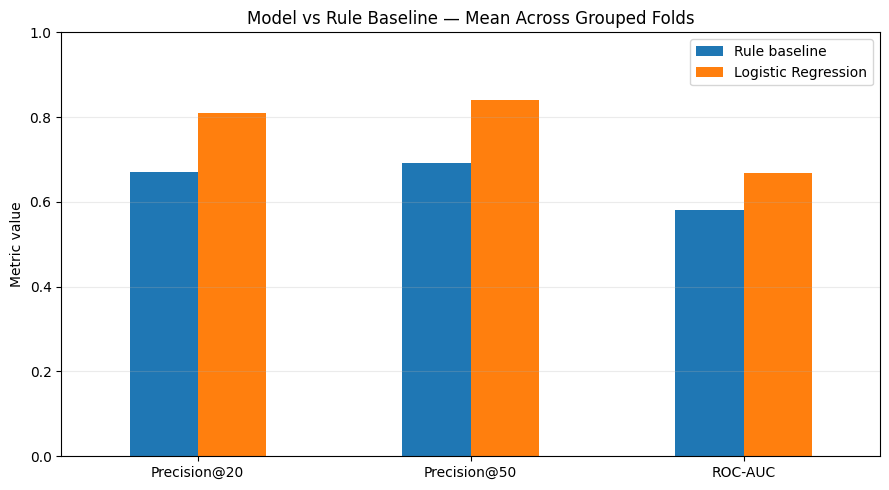

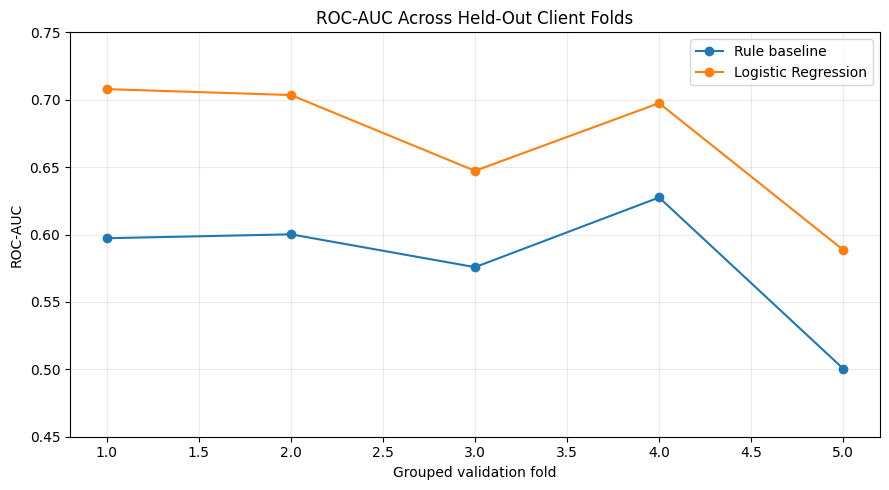


PASS: model and baseline are compared on the same grouped-validation folds.
PASS: the model has stronger mean P@20, P@50, and ROC-AUC than the transparent baseline.
PASS: fold-mean and pooled OOF metrics are reported as separate aggregation summaries.


In [4]:
# ============================================================
# Capstone — Section 4: Results vs baseline
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Honest mean-fold comparison
# ------------------------------------------------------------

results_table = pd.DataFrame([
    {
        "metric": "Precision@20",
        "baseline": fold_metrics["baseline_p20"].mean(),
        "model": fold_metrics["model_p20"].mean(),
    },
    {
        "metric": "Precision@50",
        "baseline": fold_metrics["baseline_p50"].mean(),
        "model": fold_metrics["model_p50"].mean(),
    },
    {
        "metric": "ROC-AUC",
        "baseline": fold_metrics["baseline_auc"].mean(),
        "model": fold_metrics["model_auc"].mean(),
    },
])

results_table["absolute_difference"] = (
    results_table["model"]
    - results_table["baseline"]
)

print("Mean across five grouped-validation folds")
display(results_table.round(4))


# ------------------------------------------------------------
# Fold-by-fold comparison
# ------------------------------------------------------------

fold_comparison = fold_metrics[
    [
        "fold",
        "test_rows",
        "test_clients",
        "test_base_rate",
        "baseline_p20",
        "model_p20",
        "baseline_p50",
        "model_p50",
        "baseline_auc",
        "model_auc",
    ]
].copy()

print("\nFold-by-fold results")
display(fold_comparison.round(4))


# ------------------------------------------------------------
# Consistency checks
# ------------------------------------------------------------

p20_better = int(
    (
        fold_metrics["model_p20"]
        > fold_metrics["baseline_p20"]
    ).sum()
)

p20_tied = int(
    (
        fold_metrics["model_p20"]
        == fold_metrics["baseline_p20"]
    ).sum()
)

p50_better = int(
    (
        fold_metrics["model_p50"]
        > fold_metrics["baseline_p50"]
    ).sum()
)

auc_better = int(
    (
        fold_metrics["model_auc"]
        > fold_metrics["baseline_auc"]
    ).sum()
)

model_auc_sd = (
    fold_metrics["model_auc"]
    .std(ddof=1)
)

model_auc_min = (
    fold_metrics["model_auc"]
    .min()
)

model_auc_max = (
    fold_metrics["model_auc"]
    .max()
)

print("\nCross-fold consistency")
print(
    f"Model P@20 better in {p20_better}/5 folds; "
    f"tied in {p20_tied}/5."
)
print(
    f"Model P@50 better in {p50_better}/5 folds."
)
print(
    f"Model ROC-AUC better in {auc_better}/5 folds."
)
print(
    "Model ROC-AUC SD across folds:",
    round(model_auc_sd, 4)
)
print(
    "Model ROC-AUC range:",
    f"{model_auc_min:.4f} to {model_auc_max:.4f}"
)


# ------------------------------------------------------------
# Pooled OOF model receipt
# ------------------------------------------------------------

pooled_result_table = pd.DataFrame([
    {
        "aggregation": "Pooled grouped OOF",
        "metric": "Precision@20",
        "value": precision_at_k(
            oof[TARGET],
            oof["model_score"],
            20
        )
    },
    {
        "aggregation": "Pooled grouped OOF",
        "metric": "Precision@50",
        "value": precision_at_k(
            oof[TARGET],
            oof["model_score"],
            50
        )
    },
    {
        "aggregation": "Pooled grouped OOF",
        "metric": "ROC-AUC",
        "value": roc_auc_score(
            oof[TARGET],
            oof["model_score"]
        )
    },
])

print("\nPooled OOF model metrics — separate aggregation")
display(pooled_result_table.round(4))


# ------------------------------------------------------------
# Paper figure 1:
# Mean model vs baseline
# ------------------------------------------------------------

plot_df = results_table.set_index("metric")[
    ["baseline", "model"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Model vs Rule Baseline — Mean Across Grouped Folds"
)
ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1)
ax.legend(
    ["Rule baseline", "Logistic Regression"]
)
ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=0
)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Paper figure 2:
# ROC-AUC across held-out folds
# ------------------------------------------------------------

ax = fold_metrics.plot(
    x="fold",
    y=[
        "baseline_auc",
        "model_auc"
    ],
    marker="o",
    figsize=(9, 5)
)

ax.set_title(
    "ROC-AUC Across Held-Out Client Folds"
)
ax.set_xlabel(
    "Grouped validation fold"
)
ax.set_ylabel(
    "ROC-AUC"
)
ax.set_ylim(
    0.45,
    0.75
)
ax.legend(
    ["Rule baseline", "Logistic Regression"]
)
ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Final checks
# ------------------------------------------------------------

assert (
    results_table["model"]
    > results_table["baseline"]
).all()

assert p20_better == 4
assert p20_tied == 1
assert p50_better == 5
assert auc_better == 5

assert np.isclose(
    results_table.loc[
        results_table["metric"] == "Precision@20",
        "model"
    ].iloc[0],
    0.81,
    atol=0.0001
)

assert np.isclose(
    results_table.loc[
        results_table["metric"] == "ROC-AUC",
        "model"
    ].iloc[0],
    0.6689,
    atol=0.0001
)

print(
    "\nPASS: model and baseline are compared on the same "
    "grouped-validation folds."
)

print(
    "PASS: the model has stronger mean P@20, P@50, "
    "and ROC-AUC than the transparent baseline."
)

print(
    "PASS: fold-mean and pooled OOF metrics are "
    "reported as separate aggregation summaries."
)

## 5. Limitations
## 5. Limitations

This study provides evidence about ranking performance within a specific March 2026 development experiment. It does not establish a causal relationship between editorial changes and future search performance.

### 1. The target is a proxy outcome

The target identifies whether clicks during March 25–31 are lower than clicks during March 18–24.

This is a measurable outcome, but it is not equivalent to content decay, poor content quality, or a confirmed need for a refresh.

A decline may also reflect changes in search demand, seasonality, rankings, competition, or other external factors.

### 2. The experiment uses one development month

The reported model was developed and evaluated using **March 2026**.

Five-fold grouped validation protects against training and testing on the same client within a fold, but all folds still come from the same calendar period.

The experiment therefore provides evidence about held-out client groups within March, not proof of future-period generalization.

**June 2026 remains sealed** and was not used to tune the features, model, baseline, thresholds, or action rules reported in this paper.

### 3. Performance varies across held-out client groups

The Logistic Regression model achieved a mean grouped-fold ROC-AUC of **0.6689**, but fold-level ROC-AUC ranged from **0.5886 to 0.7078**, with a standard deviation of approximately **0.0511**.

The held-out groups are also uneven: the first three folds contain one large held-out client each, while the final two contain 14 clients each.

This means that the average result should not be interpreted as identical performance for every client.

### 4. The modeling population is selected

The March source table contains **9,841,378 daily rows**, but GSC data is available for **3,611,061 rows**, approximately **36.69%** of the March daily records.

Additional modeling filters reduce the final development population to **27,186 content-level rows**.

The results therefore describe this selected modeling population rather than every content item in the warehouse.

### 5. Full-month availability is not decision-time safe

The development population requires `available_days == 31`.

Because this requirement checks availability through March 31 while the decision cutoff is March 24, it uses information from after the decision date to determine population eligibility.

This field is **not used as a model feature**, so it is not direct feature leakage. However, it is a population-selection limitation.

A live system must replace this criterion with an eligibility rule defined only from information available by the decision cutoff.

### 6. Short-window metrics can be noisy

The modeling population requires at least 20 recent impressions and more than zero recent clicks, but some items still have relatively low search exposure.

CTR and CTR-versus-expected values can be unstable for low-exposure content.

For this reason, the action playbook treats low-exposure high-score cases with additional caution rather than automatically recommending an update.

### 7. The label prevalence is relatively high

The future-click-decline outcome occurs in approximately **55.04%** of the modeling population.

For this reason, ranking metrics must be interpreted relative to this base rate rather than presented without context.

### 8. Logistic Regression is intentionally simple

The primary learned model is Logistic Regression.

The purpose of this study is to establish whether a simple and interpretable learned ranking can improve on a transparent rule baseline before introducing more complex modeling.

The study does not claim that Logistic Regression is the best possible model.

### 9. Feature coefficients are not causal effects

A positive or negative Logistic Regression coefficient indicates how a feature contributes to the model score after scaling and conditional on the other included features.

It does not establish that changing that feature would cause search performance to change.

### 10. The action thresholds are operational heuristics

The later action playbook uses score bands to create a manageable review queue.

Those thresholds are operational rules for prioritization, not learned truths about content quality.

In a real workflow, the final review depth or top-K should be chosen according to available editorial capacity and revalidated on newer data.

### 11. The model does not estimate refresh effectiveness

The model predicts the defined future-click-decline outcome.

It does not estimate:

- whether a page should be refreshed;
- what change should be made;
- whether a refresh would increase clicks;
- how large any improvement would be.

Answering those questions would require a different research design, such as a credible intervention or causal evaluation.

### Honest claim

The strongest claim supported by this study is:

> **Within the March 2026 grouped-client validation experiment, Logistic Regression ranked the defined future-click-decline outcome more effectively than the transparent rule baseline. The scores are directional decision-support for human review, not automated refresh decisions or evidence of causal refresh impact.**

In [5]:
# ============================================================
# Capstone — Section 5: Limitations and honest framing
# ============================================================

# ------------------------------------------------------------
# Evidence-backed limitation summary
# ------------------------------------------------------------

march_daily_rows = int(
    march_summary["daily_rows"].iloc[0]
)

gsc_available_rows = int(
    march_summary["gsc_available_rows"].iloc[0]
)

gsc_available_share = float(
    march_summary["gsc_available_share"].iloc[0]
)

modeling_rows = len(model_frame)

base_rate = float(
    model_frame[TARGET].mean()
)

model_auc_mean = float(
    fold_metrics["model_auc"].mean()
)

model_auc_sd = float(
    fold_metrics["model_auc"].std(ddof=1)
)

model_auc_min = float(
    fold_metrics["model_auc"].min()
)

model_auc_max = float(
    fold_metrics["model_auc"].max()
)

min_test_clients = int(
    fold_metrics["test_clients"].min()
)

max_test_clients = int(
    fold_metrics["test_clients"].max()
)


limitations_table = pd.DataFrame([
    {
        "limitation": "Single development period",
        "evidence": "March 2026 only",
        "implication":
            "Does not establish future-period generalization"
    },
    {
        "limitation": "Selected GSC population",
        "evidence":
            f"{gsc_available_rows:,} / {march_daily_rows:,} "
            f"daily rows have GSC data ({gsc_available_share:.2%})",
        "implication":
            "Results do not describe every warehouse row"
    },
    {
        "limitation": "Filtered modeling population",
        "evidence":
            f"{modeling_rows:,} final content-level rows",
        "implication":
            "Results apply to the defined eligible population"
    },
    {
        "limitation": "Population-selection timing",
        "evidence":
            "available_days == 31 uses dates after the Mar 24 cutoff",
        "implication":
            "Must be replaced by a decision-time-safe live eligibility rule"
    },
    {
        "limitation": "Outcome is a proxy",
        "evidence":
            "future clicks < recent clicks",
        "implication":
            "Does not prove content decay or need for refresh"
    },
    {
        "limitation": "Outcome prevalence",
        "evidence":
            f"Future-click-decline base rate = {base_rate:.2%}",
        "implication":
            "Precision@K must be interpreted relative to the base rate"
    },
    {
        "limitation": "Cross-client variability",
        "evidence":
            (
                f"Model AUC mean={model_auc_mean:.4f}, "
                f"SD={model_auc_sd:.4f}, "
                f"range={model_auc_min:.4f}-{model_auc_max:.4f}"
            ),
        "implication":
            "Performance is not identical across held-out client groups"
    },
    {
        "limitation": "Uneven grouped folds",
        "evidence":
            f"Held-out client count ranges from "
            f"{min_test_clients} to {max_test_clients}",
        "implication":
            "Fold averages should not be treated as uniform client performance"
    },
    {
        "limitation": "No causal intervention",
        "evidence":
            "Observational ranking experiment",
        "implication":
            "Cannot claim refreshing a page will improve performance"
    },
    {
        "limitation": "Operational action thresholds",
        "evidence":
            "Score bands are heuristic review rules",
        "implication":
            "Live top-K should reflect human review capacity and be revalidated"
    }
])

print("Evidence-backed limitations")
display(limitations_table)


# ------------------------------------------------------------
# Claim ladder
# ------------------------------------------------------------

claim_ladder = pd.DataFrame([
    {
        "claim_level": "SUPPORTED",
        "example":
            (
                "The model ranked the defined future-click-decline "
                "outcome more effectively than the rule baseline "
                "in March grouped-client validation."
            )
    },
    {
        "claim_level": "SUPPORTED WITH CAUTION",
        "example":
            (
                "The model provides a directional signal for "
                "prioritizing human editorial review."
            )
    },
    {
        "claim_level": "NOT SUPPORTED",
        "example":
            "A high-scoring page definitely needs a refresh."
    },
    {
        "claim_level": "NOT SUPPORTED",
        "example":
            "Refreshing a flagged page will increase clicks."
    },
    {
        "claim_level": "NOT SUPPORTED",
        "example":
            "The model has discovered Google's ranking algorithm."
    },
    {
        "claim_level": "NOT SUPPORTED",
        "example":
            "March performance proves equal performance for future clients."
    }
])

print("\nClaim ladder")
display(claim_ladder)


# ------------------------------------------------------------
# Reproducibility / limitation checks
# ------------------------------------------------------------

assert np.isclose(
    gsc_available_share,
    0.3669,
    atol=0.0001
)

assert modeling_rows == 27186

assert np.isclose(
    base_rate,
    0.5504,
    atol=0.0001
)

assert np.isclose(
    model_auc_mean,
    0.6689,
    atol=0.0001
)

assert np.isclose(
    model_auc_sd,
    0.0511,
    atol=0.0001
)

assert min_test_clients == 1
assert max_test_clients == 14


# June should remain outside all development windows.
assert DECISION_CUTOFF == "2026-03-24"
assert OUTCOME_END == "2026-03-31"


print(
    "\nPASS: limitations are tied to measured properties "
    "of the development experiment."
)

print(
    "PASS: March remains the development period and "
    "June remains sealed."
)

print(
    "CAUTION: full-month availability is population-selection "
    "information from after the decision cutoff."
)

print(
    "CLAIM: model scores are directional decision-support, "
    "not evidence that refreshing content will improve performance."
)

Evidence-backed limitations


,limitation,evidence,implication
0,Single development period,March 2026 only,Does not establish future-period generalization
1,Selected GSC population,"3,611,061 / 9,841,378 daily rows have GSC data...",Results do not describe every warehouse row
2,Filtered modeling population,"27,186 final content-level rows",Results apply to the defined eligible population
3,Population-selection timing,available_days == 31 uses dates after the Mar ...,Must be replaced by a decision-time-safe live ...
4,Outcome is a proxy,future clicks < recent clicks,Does not prove content decay or need for refresh
5,Outcome prevalence,Future-click-decline base rate = 55.04%,Precision@K must be interpreted relative to th...
6,Cross-client variability,"Model AUC mean=0.6689, SD=0.0511, range=0.5886...",Performance is not identical across held-out c...
7,Uneven grouped folds,Held-out client count ranges from 1 to 14,Fold averages should not be treated as uniform...
8,No causal intervention,Observational ranking experiment,Cannot claim refreshing a page will improve pe...
9,Operational action thresholds,Score bands are heuristic review rules,Live top-K should reflect human review capacit...



Claim ladder


,claim_level,example
0,SUPPORTED,The model ranked the defined future-click-decl...
1,SUPPORTED WITH CAUTION,The model provides a directional signal for pr...
2,NOT SUPPORTED,A high-scoring page definitely needs a refresh.
3,NOT SUPPORTED,Refreshing a flagged page will increase clicks.
4,NOT SUPPORTED,The model has discovered Google's ranking algo...
5,NOT SUPPORTED,March performance proves equal performance for...



PASS: limitations are tied to measured properties of the development experiment.
PASS: March remains the development period and June remains sealed.
CAUTION: full-month availability is population-selection information from after the decision cutoff.
CLAIM: model scores are directional decision-support, not evidence that refreshing content will improve performance.




## 6. Ranked recommendations

The model output is converted into a ranked editorial-review playbook rather than an automated content decision.

Each out-of-fold model score represents a **directional ranking signal** for the defined future-click-decline outcome.

The score does not determine that a page is outdated, poor quality, or in need of a refresh.

### Action policy

For this development demonstration, I use model-score quantiles to divide the ranked population into four review bands.

| Action | Rule | Intended use |
|---|---|---|
| `PRIORITY_REVIEW` | Top 5% score and not low-exposure | Inspect earlier |
| `REVIEW_WITH_CAUTION` | Top 5% score but low-exposure | Inspect only with additional skepticism |
| `WATCH` | Next 15% of scores | Monitor or review when capacity allows |
| `NO_IMMEDIATE_ACTION` | Remaining 80% | No immediate model-driven review |

These thresholds are **operational heuristics**, not learned truths.

A production workflow should choose the final top-K according to actual editorial capacity and revalidate the policy on newer data.

### Reason codes

Each surfaced item receives one or more transparent reason codes:

- `HIGH_DECLINE_SCORE` — model score falls in the highest review band;
- `ELEVATED_DECLINE_SCORE` — model score is elevated but below the highest band;
- `RECENT_CLICKS_DOWN` — recent clicks are lower than the previous seven-day window;
- `HIGH_EXPOSURE` — recent impressions are relatively high;
- `LOW_EXPOSURE_CAUTION` — recent impressions are relatively low;
- `CTR_ABOVE_EXPECTED` — recent CTR is greater than 1.20 times expected CTR for its position bucket;
- `CONFLICTING_SIGNALS` — a high model score occurs even though recent clicks are stable or increasing.

`CONFLICTING_SIGNALS` is a human-review flag, not evidence that the model contradicts itself. Logistic Regression combines several features, and a stable or increasing recent-click signal can coexist with a high model score.

### Human-review interpretation

The action bands map to different reviewer behavior:

| Archetype | Recommended action | Reviewer interpretation |
|---|---|---|
| High score + adequate exposure | `PRIORITY_REVIEW` | Inspect the page and broader search context earlier |
| High score + low exposure | `REVIEW_WITH_CAUTION` | Treat ratios and short-window movements cautiously |
| Elevated score | `WATCH` | Monitor or inspect when capacity allows |
| Lower score | `NO_IMMEDIATE_ACTION` | No immediate model-driven intervention |
| High score + stable/increasing recent clicks | Keep assigned action + context check | Do not assume the page is already declining |

### What a reviewer should check

Before making an editorial decision, the reviewer should examine:

1. whether the observed movement is large enough to matter;
2. search demand and possible seasonality;
3. impressions, CTR, and average-position movement;
4. whether the content is actually outdated, incomplete, or inaccurate;
5. business importance of the page;
6. whether model reason codes disagree with simple recent trends;
7. whether exposure is high enough for short-window ratios to be reliable.

The possible human outcomes are:

- investigate further;
- consider a refresh;
- continue monitoring;
- take no action;
- request specialist review.

### Cost and value

False positives consume editorial time by surfacing items that may not require intervention.

False negatives may delay review of items that later experience weaker click performance.

For that reason, this playbook does not send every positive model prediction to an editor. It concentrates immediate review on approximately the highest-scoring **5%** of the development population, while a broader **15%** remains in a watch band.

The value of the model is therefore in helping allocate limited human attention, not in replacing the reviewer.

### What should not be automated

The model must not automatically:

- rewrite content;
- publish content;
- change titles or metadata;
- change URLs;
- delete, redirect, or unpublish pages;
- declare that a page is “bad” or “decayed”;
- declare that a page definitely needs refreshing;
- assume that refreshing a page will improve clicks;
- allocate editorial resources solely from the model score;
- make low-exposure decisions without contextual review.

### Ranked recommendation claim

> **The model can be used to rank eligible content for human review. Higher-ranked items deserve earlier inspection under the defined playbook, but the ranking does not prescribe a specific editorial intervention.**

In [6]:
# ============================================================
# Capstone — Section 6: Ranked recommendations
# Human-review action playbook
# ============================================================

# Start from grouped out-of-fold predictions.
# Each row was scored by a model that was not trained
# on that row's held-out client group.

playbook = oof.copy()


# ------------------------------------------------------------
# Operational thresholds
# ------------------------------------------------------------

HIGH_SCORE_Q = 0.95
ELEVATED_SCORE_Q = 0.80
LOW_EXPOSURE_Q = 0.25
HIGH_EXPOSURE_Q = 0.75


high_score_threshold = float(
    playbook["model_score"].quantile(HIGH_SCORE_Q)
)

elevated_score_threshold = float(
    playbook["model_score"].quantile(ELEVATED_SCORE_Q)
)

low_exposure_threshold = float(
    playbook["recent_impressions_7d"].quantile(
        LOW_EXPOSURE_Q
    )
)

high_exposure_threshold = float(
    playbook["recent_impressions_7d"].quantile(
        HIGH_EXPOSURE_Q
    )
)


threshold_table = pd.DataFrame([
    {
        "threshold":
            "Top 5% model score",
        "value":
            high_score_threshold,
        "role":
            "Immediate-review band"
    },
    {
        "threshold":
            "Top 20% model score",
        "value":
            elevated_score_threshold,
        "role":
            "Watch-or-higher band"
    },
    {
        "threshold":
            "Low exposure Q1",
        "value":
            low_exposure_threshold,
        "role":
            "Additional caution"
    },
    {
        "threshold":
            "High exposure Q3",
        "value":
            high_exposure_threshold,
        "role":
            "Higher recent exposure"
    }
])

print("Operational thresholds")
display(threshold_table.round(4))


# ------------------------------------------------------------
# Reason codes
# ------------------------------------------------------------

def build_reason_codes(row):

    reasons = []

    if row["model_score"] >= high_score_threshold:
        reasons.append("HIGH_DECLINE_SCORE")

    elif row["model_score"] >= elevated_score_threshold:
        reasons.append("ELEVATED_DECLINE_SCORE")

    if row["pre_decision_click_change_7d"] < 0:
        reasons.append("RECENT_CLICKS_DOWN")

    if (
        row["recent_impressions_7d"]
        >= high_exposure_threshold
    ):
        reasons.append("HIGH_EXPOSURE")

    if (
        row["recent_impressions_7d"]
        <= low_exposure_threshold
    ):
        reasons.append("LOW_EXPOSURE_CAUTION")

    if row["ctr_vs_expected"] > 1.20:
        reasons.append("CTR_ABOVE_EXPECTED")

    # Human-review flag only:
    # a high score can coexist with stable/increasing recent clicks.
    if (
        row["model_score"] >= high_score_threshold
        and
        row["pre_decision_click_change_7d"] >= 0
    ):
        reasons.append("CONFLICTING_SIGNALS")

    return " | ".join(reasons)


playbook["reason_codes"] = playbook.apply(
    build_reason_codes,
    axis=1
)


# ------------------------------------------------------------
# Action assignment
# ------------------------------------------------------------

def assign_action(row):

    if row["model_score"] >= high_score_threshold:

        if (
            row["recent_impressions_7d"]
            <= low_exposure_threshold
        ):
            return "REVIEW_WITH_CAUTION"

        return "PRIORITY_REVIEW"

    if row["model_score"] >= elevated_score_threshold:
        return "WATCH"

    return "NO_IMMEDIATE_ACTION"


playbook["action"] = playbook.apply(
    assign_action,
    axis=1
)


# ------------------------------------------------------------
# Rank all rows
# ------------------------------------------------------------

playbook = (
    playbook
    .sort_values(
        "model_score",
        ascending=False
    )
    .reset_index(drop=True)
)

playbook["rank"] = (
    np.arange(
        1,
        len(playbook) + 1
    )
)


# ------------------------------------------------------------
# Action distribution
# ------------------------------------------------------------

action_order = [
    "PRIORITY_REVIEW",
    "REVIEW_WITH_CAUTION",
    "WATCH",
    "NO_IMMEDIATE_ACTION",
]

action_distribution = (
    playbook["action"]
    .value_counts()
    .reindex(
        action_order,
        fill_value=0
    )
    .rename_axis("action")
    .reset_index(name="rows")
)

action_distribution["share"] = (
    action_distribution["rows"]
    / len(playbook)
)

print("\nAction distribution")
display(
    action_distribution.round(4)
)


# ------------------------------------------------------------
# Immediate-review workload
# ------------------------------------------------------------

review_actions = {
    "PRIORITY_REVIEW",
    "REVIEW_WITH_CAUTION",
}

review_pool = playbook[
    playbook["action"].isin(
        review_actions
    )
].copy()

review_rows = len(review_pool)

review_share = (
    review_rows
    / len(playbook)
)

low_exposure_review_share = (
    review_pool[
        "reason_codes"
    ]
    .str.contains(
        "LOW_EXPOSURE_CAUTION",
        regex=False
    )
    .mean()
)

conflicting_review_share = (
    review_pool[
        "reason_codes"
    ]
    .str.contains(
        "CONFLICTING_SIGNALS",
        regex=False
    )
    .mean()
)

recent_clicks_down_share = (
    review_pool[
        "reason_codes"
    ]
    .str.contains(
        "RECENT_CLICKS_DOWN",
        regex=False
    )
    .mean()
)


review_audit = pd.DataFrame([
    {
        "measure":
            "Immediate-review rows",
        "value":
            review_rows
    },
    {
        "measure":
            "Immediate-review share",
        "value":
            review_share
    },
    {
        "measure":
            "Low-exposure caution share "
            "within review pool",
        "value":
            low_exposure_review_share
    },
    {
        "measure":
            "Conflicting-signal share "
            "within review pool",
        "value":
            conflicting_review_share
    },
    {
        "measure":
            "Recent-clicks-down share "
            "within review pool",
        "value":
            recent_clicks_down_share
    }
])

print("\nImmediate-review audit")
display(
    review_audit.round(4)
)


# ------------------------------------------------------------
# Public-safe ranked preview
# No client hash, content hash, URL, query, or future label.
# ------------------------------------------------------------

public_preview_columns = [
    "rank",
    "model_score",
    "action",
    "reason_codes",
    "recent_impressions_7d",
    "recent_clicks_7d",
    "pre_decision_click_change_7d",
    "recent_ctr",
    "recent_avg_position",
    "ctr_vs_expected",
]

public_preview = (
    playbook[
        public_preview_columns
    ]
    .head(20)
    .copy()
)

print("\nPublic-safe top-20 ranked preview")
display(
    public_preview.round(4)
)


# ------------------------------------------------------------
# Archetype -> action map
# ------------------------------------------------------------

archetype_map = pd.DataFrame([
    {
        "archetype":
            "High score + adequate exposure",
        "action":
            "PRIORITY_REVIEW",
        "interpretation":
            "Inspect earlier; human context still required"
    },
    {
        "archetype":
            "High score + low exposure",
        "action":
            "REVIEW_WITH_CAUTION",
        "interpretation":
            "Short-window ratios may be unstable"
    },
    {
        "archetype":
            "Elevated score",
        "action":
            "WATCH",
        "interpretation":
            "Monitor or review when capacity allows"
    },
    {
        "archetype":
            "Lower score",
        "action":
            "NO_IMMEDIATE_ACTION",
        "interpretation":
            "No immediate model-driven review"
    },
    {
        "archetype":
            "High score + non-declining recent clicks",
        "action":
            "KEEP_ASSIGNED_ACTION",
        "interpretation":
            (
                "CONFLICTING_SIGNALS is a context flag; "
                "do not override the queue automatically"
            )
    }
])

print("\nArchetype-to-action map")
display(archetype_map)


# ------------------------------------------------------------
# No-go automation list
# ------------------------------------------------------------

no_go_actions = pd.DataFrame([
    {
        "automatic_action":
            "Rewrite content",
        "allowed":
            False
    },
    {
        "automatic_action":
            "Publish content",
        "allowed":
            False
    },
    {
        "automatic_action":
            "Change title or metadata",
        "allowed":
            False
    },
    {
        "automatic_action":
            "Change URL",
        "allowed":
            False
    },
    {
        "automatic_action":
            "Delete / redirect / unpublish",
        "allowed":
            False
    },
    {
        "automatic_action":
            "Declare content bad or decayed",
        "allowed":
            False
    },
    {
        "automatic_action":
            "Declare refresh required",
        "allowed":
            False
    },
    {
        "automatic_action":
            "Claim refresh will improve clicks",
        "allowed":
            False
    }
])

print("\nNo-go automation list")
display(no_go_actions)


# ------------------------------------------------------------
# Safety / consistency checks
# ------------------------------------------------------------

assert len(playbook) == 27186

assert (
    action_distribution["rows"].sum()
    == len(playbook)
)

assert (
    no_go_actions["allowed"]
    .sum()
    == 0
)

assert (
    "client_hash_id"
    not in public_preview.columns
)

assert (
    "content_hash_id"
    not in public_preview.columns
)

assert (
    TARGET
    not in public_preview.columns
)

assert (
    "future_clicks_7d"
    not in public_preview.columns
)

# The quantile policy should surface roughly 5%
# for immediate review.
assert 0.049 <= review_share <= 0.051


print(
    "\nPASS: every row receives a ranked human-review action."
)

print(
    "PASS: the immediate-review band is approximately "
    "5% of the March development population."
)

print(
    "PASS: the public preview contains no client/content "
    "identifiers or future outcome fields."
)

print(
    "PASS: no editorial action is authorized for automatic execution."
)

print(
    "CLAIM: the queue prioritizes human inspection; "
    "it does not prescribe a refresh."
)

Operational thresholds


,threshold,value,role
0,Top 5% model score,0.8125,Immediate-review band
1,Top 20% model score,0.6595,Watch-or-higher band
2,Low exposure Q1,327.0000,Additional caution
3,High exposure Q3,1656.0000,Higher recent exposure



Action distribution


,action,rows,share
0,PRIORITY_REVIEW,328,0.0121
1,REVIEW_WITH_CAUTION,1032,0.0380
2,WATCH,4078,0.1500
3,NO_IMMEDIATE_ACTION,21748,0.8000



Immediate-review audit


...


Archetype-to-action map


,archetype,action,interpretation
0,High score + adequate exposure,PRIORITY_REVIEW,Inspect earlier; human context still required
1,High score + low exposure,REVIEW_WITH_CAUTION,Short-window ratios may be unstable
2,Elevated score,WATCH,Monitor or review when capacity allows
3,Lower score,NO_IMMEDIATE_ACTION,No immediate model-driven review
4,High score + non-declining recent clicks,KEEP_ASSIGNED_ACTION,CONFLICTING_SIGNALS is a context flag; do not ...



No-go automation list


,automatic_action,allowed
0,Rewrite content,False
1,Publish content,False
2,Change title or metadata,False
3,Change URL,False
4,Delete / redirect / unpublish,False
5,Declare content bad or decayed,False
6,Declare refresh required,False
7,Claim refresh will improve clicks,False



PASS: every row receives a ranked human-review action.
PASS: the immediate-review band is approximately 5% of the March development population.
PASS: the public preview contains no client/content identifiers or future outcome fields.
PASS: no editorial action is authorized for automatic execution.
CLAIM: the queue prioritizes human inspection; it does not prescribe a refresh.


## 7. Artifacts the paper embeds
## 7. Artifacts the paper embeds

The deployed research page uses only aggregate, public-safe evidence generated from this notebook.

### Paper figures

The notebook exports four figures:

1. **Model vs rule baseline** — mean Precision@20, Precision@50, and ROC-AUC across the five grouped-client folds.
2. **ROC-AUC by fold** — shows variation across held-out client groups rather than hiding it behind a single average.
3. **Action distribution** — shows how the playbook allocates the March development population across review bands.
4. **Model score by action** — shows how the operational action bands relate to grouped out-of-fold model scores.

### Metrics receipt

A compact JSON receipt records the exact public numbers used by the deployed paper, including:

- data-release and March population statistics;
- outcome base rate;
- fold-mean model-versus-baseline results;
- pooled grouped out-of-fold model metrics;
- cross-fold variability;
- action thresholds and action distribution;
- human-review workload indicators;
- reproducibility and claim-framing notes.

The receipt contains no client names, URLs, private queries, client hashes, content hashes, or row-level future outcomes.

### Reproducibility

The research notebook records:

- warehouse release `v20260703`;
- March 2026 as the development period;
- March 24 as the decision cutoff;
- March 25–31 as the outcome window;
- five-fold `GroupKFold` validation by anonymized client;
- Logistic Regression with `random_state=42`;
- the six model features;
- the transparent baseline;
- leakage checks;
- the action-playbook rules.

June 2026 remains sealed and is not used in the results presented here.

Anyone reviewing the repository can inspect the notebook logic and the aggregate paper artifacts. Access to the underlying internship warehouse may still require the appropriate dataset credentials.

### Acknowledgments & data credit

**Built on the [FlyRank ML Internship dataset](https://flyrank.ai).**

I acknowledge FlyRank for providing the anonymized internship warehouse used for this study.

### Public-safety rule

The deployed paper may show aggregate metrics, aggregate figures, methodology, and anonymized research framing.

It must not show client names, client URLs, page URLs, private queries, client hashes, content hashes, or row-level identifying information.

Repository clone not found — cloning...
Figure directory: /content/flyrank-machine-learning-internship/work/figures
Output directory: /content/flyrank-machine-learning-internship/work/outputs


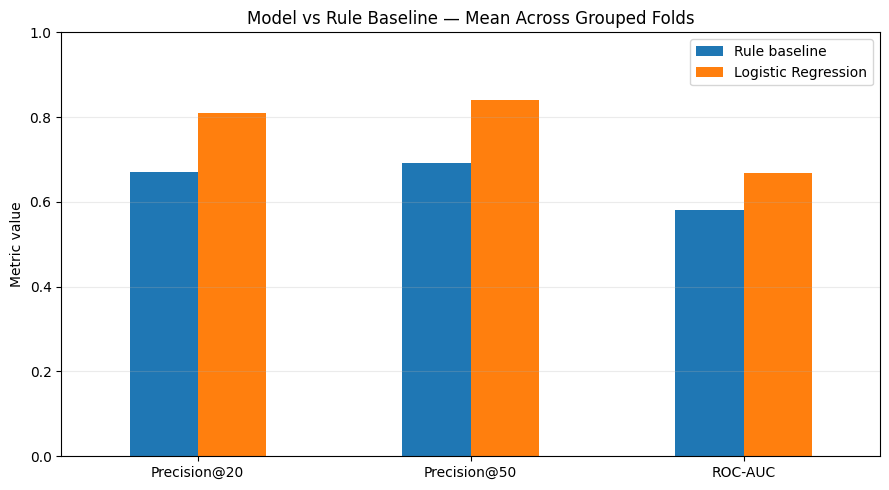

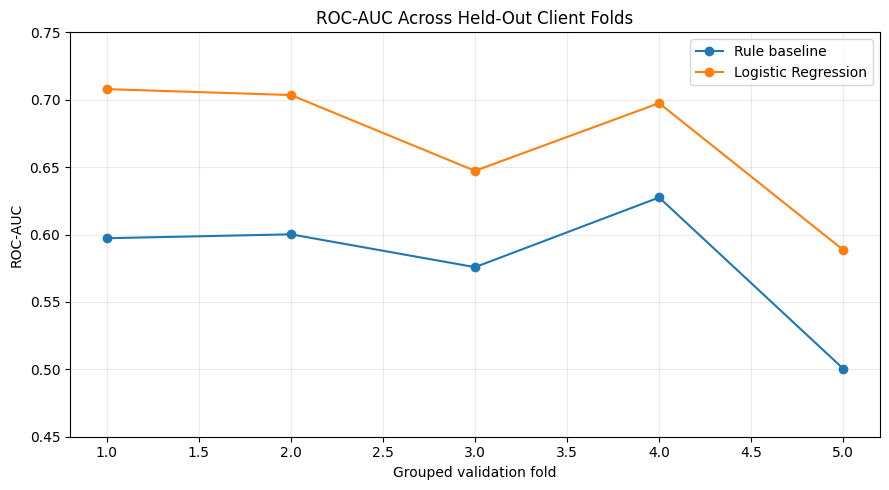

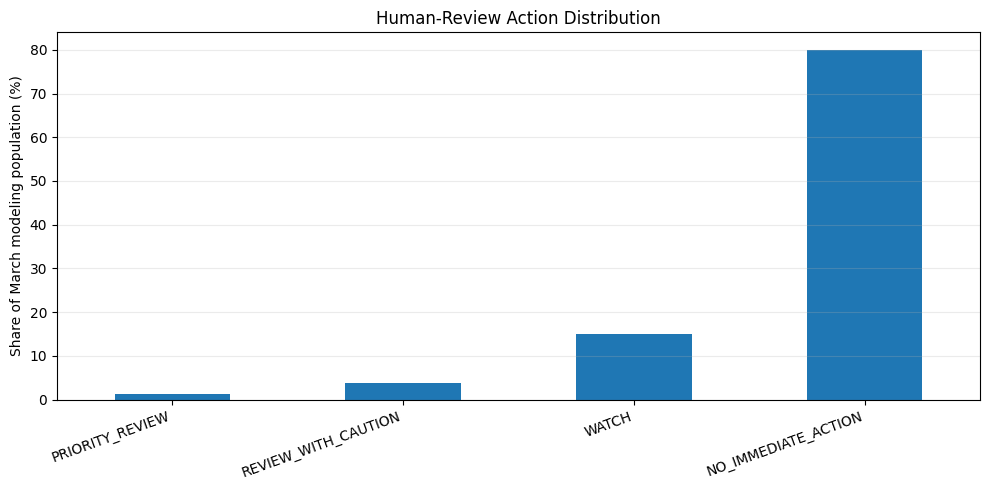

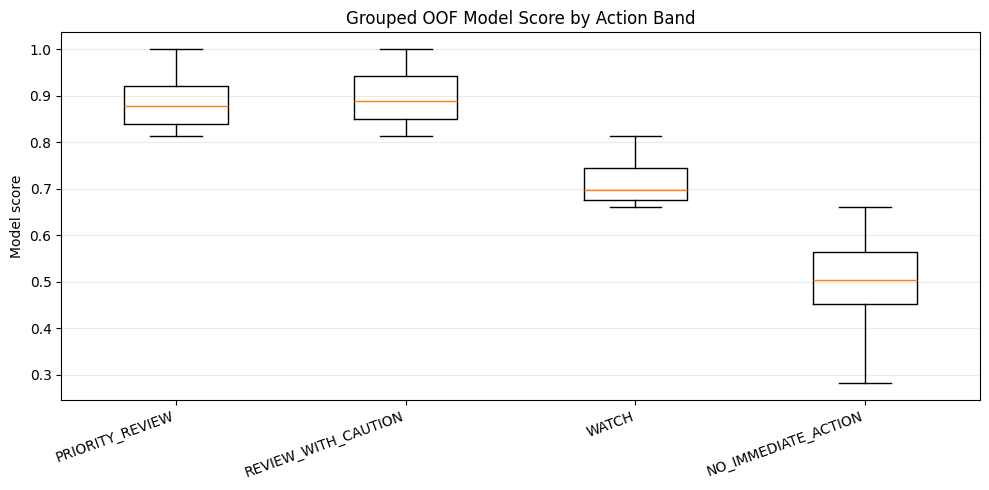


Paper artifact receipt


,artifact,exists,size_bytes,repo_relative_path
0,capstone_model_vs_baseline.png,True,49434,work/figures/capstone_model_vs_baseline.png
1,capstone_auc_by_fold.png,True,90631,work/figures/capstone_auc_by_fold.png
2,capstone_action_distribution.png,True,82279,work/figures/capstone_action_distribution.png
3,capstone_score_by_action.png,True,78902,work/figures/capstone_score_by_action.png
4,capstone_paper_metrics.json,True,4203,work/outputs/capstone_paper_metrics.json
5,capstone_fold_results.json,True,1278,work/outputs/capstone_fold_results.json



PASS: public-safe paper figures were exported.
PASS: aggregate metrics receipts were exported.
PASS: no client/content identifiers or private queries are included in paper artifacts.
PASS: March remains the reported development period and June remains sealed.
READY: these artifacts can now be embedded in the deployed ML-11 research page.


In [7]:
# ============================================================
# Capstone — Section 7: Paper artifacts
# Exports public-safe figures + aggregate metrics receipt
# ============================================================

from pathlib import Path
import json
import subprocess
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Ensure a local clone exists
# ------------------------------------------------------------

REPO_DIR = Path(
    "/content/flyrank-machine-learning-internship"
)

REPO_URL = (
    "https://github.com/shaestasaleem/"
    "flyrank-machine-learning-internship.git"
)

if not REPO_DIR.exists():
    print("Repository clone not found — cloning...")
    subprocess.run(
        [
            "git",
            "clone",
            REPO_URL,
            str(REPO_DIR)
        ],
        check=True
    )
else:
    print(
        "Repository clone already exists:",
        REPO_DIR
    )


FIGURE_DIR = (
    REPO_DIR
    / "work"
    / "figures"
)

OUTPUT_DIR = (
    REPO_DIR
    / "work"
    / "outputs"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Figure directory:", FIGURE_DIR)
print("Output directory:", OUTPUT_DIR)


# ------------------------------------------------------------
# 2. Figure: model vs baseline
# ------------------------------------------------------------

model_vs_baseline_path = (
    FIGURE_DIR
    / "capstone_model_vs_baseline.png"
)

plot_df = (
    results_table
    .set_index("metric")[
        ["baseline", "model"]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Model vs Rule Baseline — Mean Across Grouped Folds"
)

ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1)

ax.legend(
    [
        "Rule baseline",
        "Logistic Regression"
    ]
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    model_vs_baseline_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 3. Figure: AUC across held-out client folds
# ------------------------------------------------------------

auc_by_fold_path = (
    FIGURE_DIR
    / "capstone_auc_by_fold.png"
)

ax = fold_metrics.plot(
    x="fold",
    y=[
        "baseline_auc",
        "model_auc"
    ],
    marker="o",
    figsize=(9, 5)
)

ax.set_title(
    "ROC-AUC Across Held-Out Client Folds"
)

ax.set_xlabel(
    "Grouped validation fold"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_ylim(
    0.45,
    0.75
)

ax.legend(
    [
        "Rule baseline",
        "Logistic Regression"
    ]
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    auc_by_fold_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 4. Figure: action distribution
# ------------------------------------------------------------

action_distribution_path = (
    FIGURE_DIR
    / "capstone_action_distribution.png"
)

action_plot = (
    action_distribution
    .copy()
)

action_plot["share_percent"] = (
    action_plot["share"] * 100
)

ax = action_plot.plot(
    x="action",
    y="share_percent",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

ax.set_title(
    "Human-Review Action Distribution"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Share of March modeling population (%)"
)

plt.xticks(
    rotation=20,
    ha="right"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    action_distribution_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 5. Figure: model score by action
# ------------------------------------------------------------

score_by_action_path = (
    FIGURE_DIR
    / "capstone_score_by_action.png"
)

score_plot_data = [
    playbook.loc[
        playbook["action"] == action,
        "model_score"
    ].values
    for action in action_order
]

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.boxplot(
    score_plot_data,
    tick_labels=action_order,
    showfliers=False
)

ax.set_title(
    "Grouped OOF Model Score by Action Band"
)

ax.set_ylabel(
    "Model score"
)

ax.set_xlabel("")

plt.xticks(
    rotation=20,
    ha="right"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    score_by_action_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. Build public-safe aggregate metrics receipt
# ------------------------------------------------------------

def action_count(action_name):
    return int(
        action_distribution.loc[
            action_distribution["action"]
            == action_name,
            "rows"
        ].iloc[0]
    )


def action_share(action_name):
    return float(
        action_distribution.loc[
            action_distribution["action"]
            == action_name,
            "share"
        ].iloc[0]
    )


paper_metrics = {

    "assignment": "ML-11",

    "research_question": RESEARCH_QUESTION,

    "data": {
        "warehouse_release":
            RELEASE_BUILD,

        "development_period":
            "2026-03",

        "march_daily_rows":
            int(
                march_summary[
                    "daily_rows"
                ].iloc[0]
            ),

        "anonymized_clients":
            int(
                march_summary[
                    "anonymized_clients"
                ].iloc[0]
            ),

        "anonymized_content_items":
            int(
                march_summary[
                    "anonymized_content_items"
                ].iloc[0]
            ),

        "gsc_available_rows":
            int(
                march_summary[
                    "gsc_available_rows"
                ].iloc[0]
            ),

        "gsc_available_share":
            float(
                march_summary[
                    "gsc_available_share"
                ].iloc[0]
            ),

        "modeling_rows":
            int(len(model_frame)),

        "future_decline_rows":
            int(
                model_frame[
                    TARGET
                ].sum()
            ),

        "future_decline_base_rate":
            float(
                model_frame[
                    TARGET
                ].mean()
            ),

        "decision_cutoff":
            DECISION_CUTOFF,

        "outcome_window":
            "2026-03-25 to 2026-03-31",

        "sealed_period":
            "2026-06"
    },


    "methodology": {

        "model":
            "Logistic Regression",

        "validation":
            "5-fold GroupKFold by anonymized client",

        "random_seed":
            RANDOM_SEED,

        "features":
            FEATURES,

        "baseline":
            (
                "Recent click increase > 0 AND "
                "ctr_vs_expected > 1.20; "
                "eligible rows ranked by recent impressions"
            ),

        "population_selection_caution":
            (
                "Development population requires "
                "available_days == 31, which uses dates "
                "after the March 24 decision cutoff. "
                "This is not a model feature but is not "
                "decision-time-safe for live eligibility."
            )
    },


    "fold_mean_results": {

        "precision_at_20": {
            "baseline":
                float(
                    fold_metrics[
                        "baseline_p20"
                    ].mean()
                ),

            "model":
                float(
                    fold_metrics[
                        "model_p20"
                    ].mean()
                )
        },

        "precision_at_50": {
            "baseline":
                float(
                    fold_metrics[
                        "baseline_p50"
                    ].mean()
                ),

            "model":
                float(
                    fold_metrics[
                        "model_p50"
                    ].mean()
                )
        },

        "roc_auc": {
            "baseline":
                float(
                    fold_metrics[
                        "baseline_auc"
                    ].mean()
                ),

            "model":
                float(
                    fold_metrics[
                        "model_auc"
                    ].mean()
                )
        }
    },


    "pooled_grouped_oof_model": {

        "precision_at_20":
            float(
                precision_at_k(
                    oof[TARGET],
                    oof["model_score"],
                    20
                )
            ),

        "precision_at_50":
            float(
                precision_at_k(
                    oof[TARGET],
                    oof["model_score"],
                    50
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    oof[TARGET],
                    oof["model_score"]
                )
            ),

        "note":
            (
                "These pooled OOF metrics are a separate "
                "aggregation from the mean of fold-level metrics."
            )
    },


    "cross_fold_variability": {

        "model_auc_sd":
            float(
                fold_metrics[
                    "model_auc"
                ].std(ddof=1)
            ),

        "model_auc_min":
            float(
                fold_metrics[
                    "model_auc"
                ].min()
            ),

        "model_auc_max":
            float(
                fold_metrics[
                    "model_auc"
                ].max()
            ),

        "model_p20_better_folds":
            int(p20_better),

        "model_p20_tied_folds":
            int(p20_tied),

        "model_p50_better_folds":
            int(p50_better),

        "model_auc_better_folds":
            int(auc_better)
    },


    "playbook": {

        "top_5_percent_score_threshold":
            high_score_threshold,

        "top_20_percent_score_threshold":
            elevated_score_threshold,

        "low_exposure_q1":
            low_exposure_threshold,

        "high_exposure_q3":
            high_exposure_threshold,

        "priority_review": {
            "rows":
                action_count(
                    "PRIORITY_REVIEW"
                ),

            "share":
                action_share(
                    "PRIORITY_REVIEW"
                )
        },

        "review_with_caution": {
            "rows":
                action_count(
                    "REVIEW_WITH_CAUTION"
                ),

            "share":
                action_share(
                    "REVIEW_WITH_CAUTION"
                )
        },

        "watch": {
            "rows":
                action_count(
                    "WATCH"
                ),

            "share":
                action_share(
                    "WATCH"
                )
        },

        "no_immediate_action": {
            "rows":
                action_count(
                    "NO_IMMEDIATE_ACTION"
                ),

            "share":
                action_share(
                    "NO_IMMEDIATE_ACTION"
                )
        },

        "immediate_review_rows":
            int(review_rows),

        "immediate_review_share":
            float(review_share),

        "low_exposure_caution_share_review_pool":
            float(
                low_exposure_review_share
            ),

        "conflicting_signal_share_review_pool":
            float(
                conflicting_review_share
            ),

        "recent_clicks_down_share_review_pool":
            float(
                recent_clicks_down_share
            ),

        "threshold_note":
            (
                "Action thresholds are operational heuristics. "
                "A live top-K should reflect available "
                "human review capacity."
            )
    },


    "claim_framing": {

        "supported_claim":
            (
                "Within the March 2026 grouped-client "
                "validation experiment, Logistic Regression "
                "ranked the defined future-click-decline "
                "outcome more effectively than the "
                "transparent rule baseline."
            ),

        "intended_use":
            (
                "Directional decision-support for "
                "human editorial review."
            ),

        "not_supported": [
            "A high-scoring page definitely requires refresh.",
            "Refreshing a flagged page will increase clicks.",
            "The model establishes causal refresh impact.",
            "The model discovered a search-engine ranking algorithm."
        ]
    },


    "public_safety": {
        "contains_client_names":
            False,

        "contains_urls":
            False,

        "contains_private_queries":
            False,

        "contains_client_hashes":
            False,

        "contains_content_hashes":
            False,

        "contains_row_level_future_outcomes":
            False
    },


    "data_credit": {
        "text":
            "Built on the FlyRank ML Internship dataset",

        "url":
            "https://flyrank.ai"
    }
}


metrics_path = (
    OUTPUT_DIR
    / "capstone_paper_metrics.json"
)

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        paper_metrics,
        f,
        indent=2,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 7. Export fold-level aggregate paper table
# JSON keeps it easy to consume from the deployed page.
# ------------------------------------------------------------

fold_table_path = (
    OUTPUT_DIR
    / "capstone_fold_results.json"
)

public_fold_table = (
    fold_comparison
    .round(6)
    .to_dict(
        orient="records"
    )
)

with open(
    fold_table_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        public_fold_table,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 8. Verify exported artifacts
# ------------------------------------------------------------

artifact_paths = [
    model_vs_baseline_path,
    auc_by_fold_path,
    action_distribution_path,
    score_by_action_path,
    metrics_path,
    fold_table_path,
]

artifact_receipt = []

for path in artifact_paths:

    artifact_receipt.append({
        "artifact":
            path.name,

        "exists":
            path.exists(),

        "size_bytes":
            path.stat().st_size
            if path.exists()
            else 0,

        "repo_relative_path":
            str(
                path.relative_to(
                    REPO_DIR
                )
            )
    })


artifact_receipt = pd.DataFrame(
    artifact_receipt
)

print("\nPaper artifact receipt")
display(artifact_receipt)


# ------------------------------------------------------------
# 9. Final public-safety checks
# ------------------------------------------------------------

assert all(
    artifact_receipt["exists"]
)

assert all(
    artifact_receipt[
        "size_bytes"
    ] > 0
)

assert (
    paper_metrics[
        "public_safety"
    ][
        "contains_client_names"
    ]
    is False
)

assert (
    paper_metrics[
        "public_safety"
    ][
        "contains_urls"
    ]
    is False
)

assert (
    paper_metrics[
        "public_safety"
    ][
        "contains_private_queries"
    ]
    is False
)

assert (
    paper_metrics[
        "public_safety"
    ][
        "contains_client_hashes"
    ]
    is False
)

assert (
    paper_metrics[
        "public_safety"
    ][
        "contains_content_hashes"
    ]
    is False
)

assert (
    paper_metrics[
        "data"
    ][
        "sealed_period"
    ]
    == "2026-06"
)


print(
    "\nPASS: public-safe paper figures were exported."
)

print(
    "PASS: aggregate metrics receipts were exported."
)

print(
    "PASS: no client/content identifiers or private "
    "queries are included in paper artifacts."
)

print(
    "PASS: March remains the reported development "
    "period and June remains sealed."
)

print(
    "READY: these artifacts can now be embedded "
    "in the deployed ML-11 research page."
)

### Paper artifact interpretation

The capstone export produced four reusable figures and two aggregate metric
receipts for the deployed research page.

The validation figures summarize model-versus-baseline ranking performance
and variation across grouped client folds. The action-playbook figures show
how the validated out-of-fold scores were translated into a conservative
human-review workflow.

These figures represent two related but different views of the March 2026
development results:

- Fold-level validation summarizes performance within each grouped
  client-validation fold.
- The action-playbook analysis uses the combined out-of-fold predictions to
  construct operational review bands across the full March development
  population.

For that reason, fold-average metrics and pooled out-of-fold metrics should
be labeled separately rather than treated as interchangeable.

Only aggregate, public-safe evidence is exported for the research page.
Client identifiers, content identifiers, URLs, private queries, and future
outcome fields are not included.

March 2026 remains the development period. June 2026 remains sealed and is
not used to strengthen the current research claims.

## Final paper-artifact self-check

- [x] Model-versus-baseline figure exported.
- [x] AUC-by-fold figure exported.
- [x] Action-distribution figure exported.
- [x] Score-by-action figure exported.
- [x] Aggregate paper metrics JSON exported.
- [x] Fold-results JSON exported.
- [x] Figures contain only public-safe aggregate information.
- [x] No client names, content identifiers, URLs, or private queries are exposed.
- [x] March 2026 is clearly labeled as the development period.
- [x] June 2026 remains sealed.
- [x] Fold-average and pooled out-of-fold metrics are not mixed.
- [x] Claims remain directional and decision-support oriented.
- [x] No causal claim is made that refreshing content will improve clicks.

**Status:** Paper artifacts are ready to be used in the ML-11 deployed
research page.